In [1]:
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline


from utils import QACC_utils
#from utils.config import model, min_lat_arctic, max_lat_arctic, min_lat_tropics, max_lat_tropics, min_year_late_cent, max_year_late_cent

##### SETTINGS
model = 'UKESM1-0-LL'
#min_lat_arctic, max_lat_arctic = 66, 90
#min_lat_tropics, max_lat_tropics = -23, 23


regions = ['Arctic', 'Tropics']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23]}

scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']

experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}

time_slice_dict = {'ssp245':['2050', '2070'], 
                   'ARISE':['2050', '2070'],
                   'ssp245_baseline':['2015', '2030']}

In [2]:
dict_list = []
for scen in scenarios:
    ds_list = []
    for region in regions:
        ds =  xr.open_dataset('intermediate_outputs/init/{s}_{l}_{m}_{r}_alllevs.nc'.format(
            s=scen, l=str(lat_band_dict[region][0]), r=region, m=model))
        ds_list.append(ds)
    scen_dict = dict(zip(regions, ds_list))
    dict_list.append(scen_dict)
spatial_means_dict = dict(zip(scenarios, dict_list))

In [3]:
spatial_means_dict['ARISE']['Arctic']['ta']

<xarray.DataArray 'ta' (month: 12, plev: 19)> Size: 2kB
[228 values with dtype=float64]
Coordinates:
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

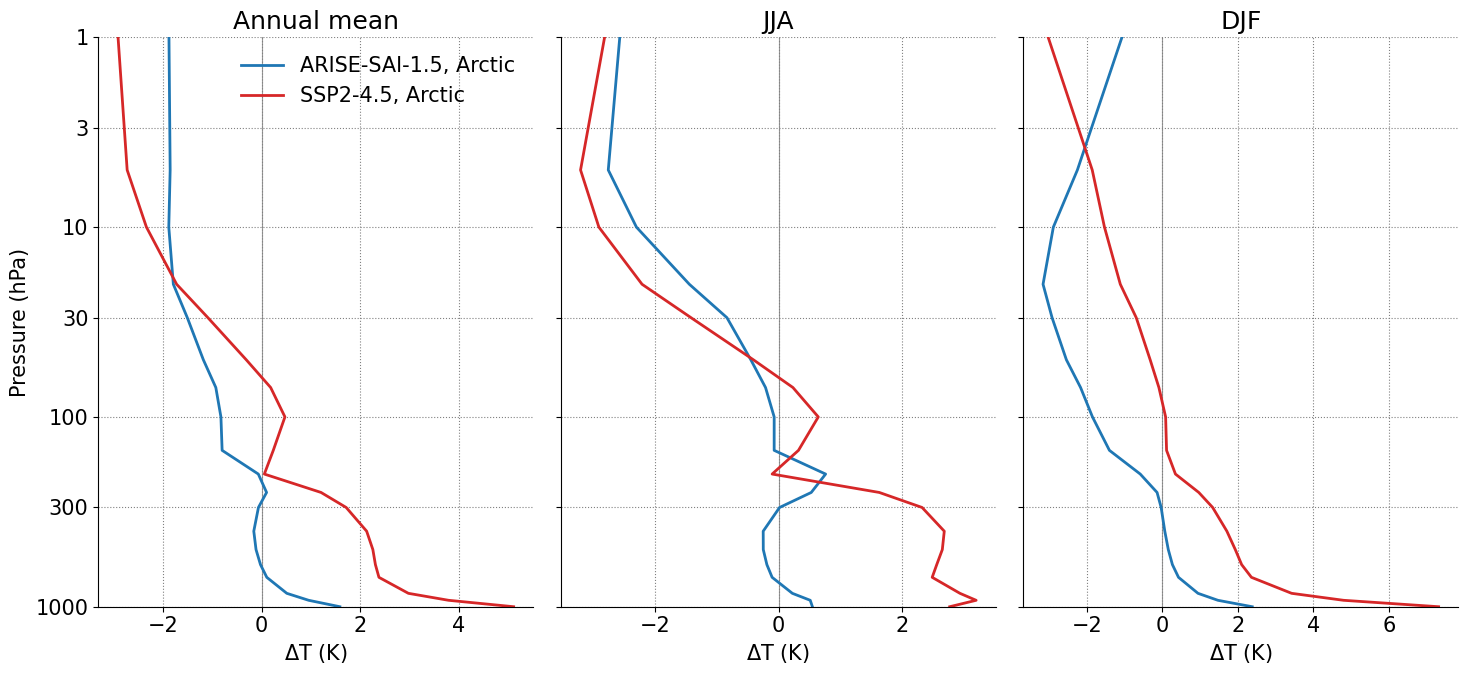

In [4]:
##### DELTA-T PROFILES: ARISE and SSP2-4.5 relative to the SSP2-4.5 baseline

import matplotlib.ticker as mticker

season_dict = {'Annual mean': None,          # None -> mean over all 12 months
               'JJA': [6, 7, 8],
               'DJF': [12, 1, 2]}

scen_colors = {'ARISE': 'tab:blue', 'ssp245': 'tab:red'}
scen_labels = {'ARISE': 'ARISE-SAI-1.5', 'ssp245': 'SSP2-4.5'}
region_ls = {'Arctic': '-', 'Tropics': '--'}

regions_to_plot = ['Arctic']#, 'Tropics']      # set to ['Arctic'] for Arctic only

FS = 15
plt.rcParams.update({'font.size': FS})


def seasonal_mean(da, months):
    """Mean over selected months of a monthly climatology.
    UKESM1-0-LL runs on a 360_day calendar (all months 30 days), so an
    unweighted mean over months is exact - no day-length weighting needed."""
    if months is None:
        return da.mean('month')
    return da.sel(month=months).mean('month')


fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)

for ax, (season, months) in zip(axes, season_dict.items()):
    for region in regions_to_plot:
        base = spatial_means_dict['ssp245_baseline'][region]['ta']
        for scen in ['ARISE', 'ssp245']:
            dT = (seasonal_mean(spatial_means_dict[scen][region]['ta'], months)
                  - seasonal_mean(base, months))
            ax.plot(dT.values, dT['plev'].values / 100.,
                    color=scen_colors[scen], linestyle=region_ls[region], lw=2,
                    label='{s}, {r}'.format(s=scen_labels[scen], r=region))

    ax.axvline(0, color='0.6', lw=0.8, zorder=0)
    ax.set_title(season, fontsize='large')
    ax.set_xlabel(r'$\Delta$T (K)', fontsize='medium')

    ax.set_yscale('log')
    ax.set_ylim(1000, 1)                     # hPa, inverted (surface at bottom)
    ax.set_yticks([1000, 300, 100, 30, 10, 3, 1])
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.minorticks_off()

    ax.tick_params(axis='both', labelsize='medium')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted', color='gray')

axes[0].set_ylabel('Pressure (hPa)', fontsize='medium')
axes[0].legend(fontsize='medium', frameon=False, loc='upper right')

"""
fig.suptitle('{m}: temperature response relative to SSP2-4.5 baseline '
             '({b0}-{b1})'.format(m=model,
                                  b0=time_slice_dict['ssp245_baseline'][0],
                                  b1=time_slice_dict['ssp245_baseline'][1]),
             fontsize='large')
"""

fig.tight_layout()
plt.show()

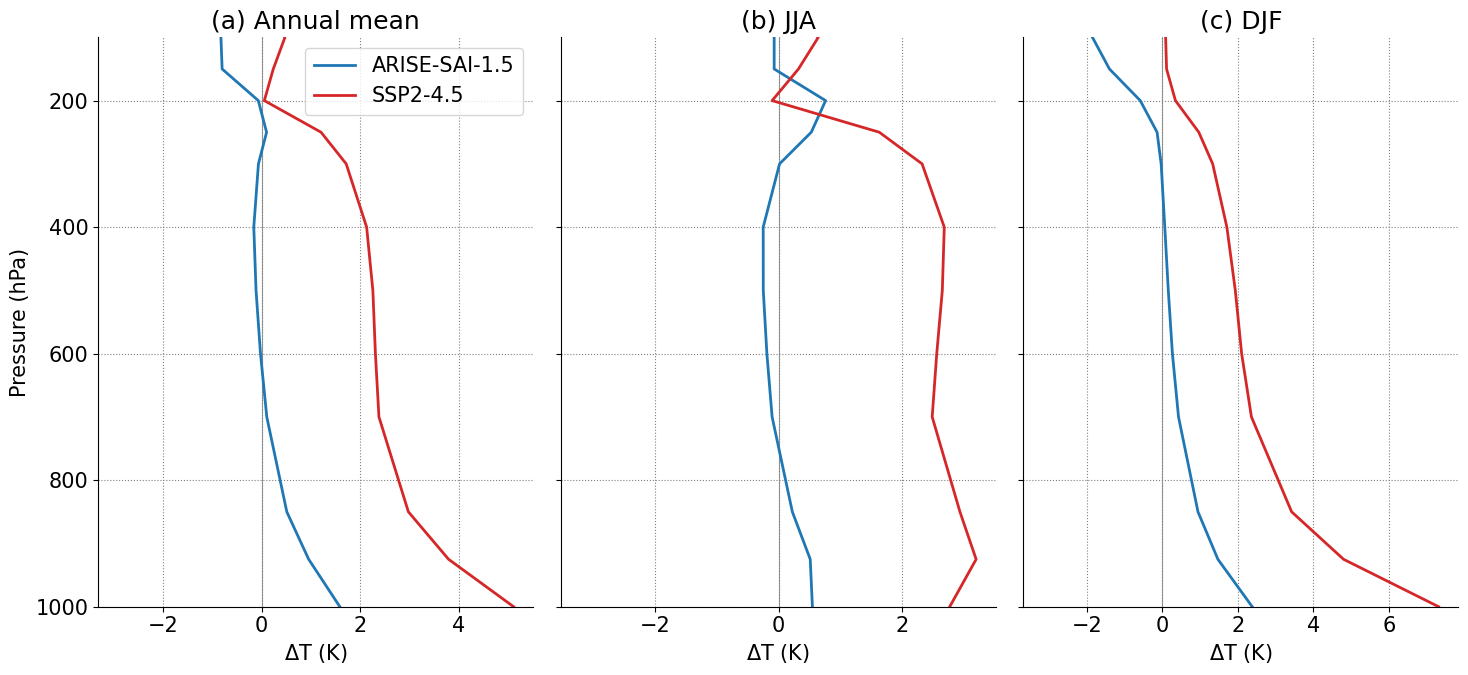

In [7]:
##### DELTA-T PROFILES: ARISE and SSP2-4.5 relative to the SSP2-4.5 baseline
season_dict = {'Annual mean': None,          # None -> mean over all 12 months
               'JJA': [6, 7, 8],
               'DJF': [12, 1, 2]}
scen_colors = {'ARISE': 'tab:blue', 'ssp245': 'tab:red'}
scen_labels = {'ARISE': 'ARISE-SAI-1.5', 'ssp245': 'SSP2-4.5'}
region_ls = {'Arctic': '-', 'Tropics': '--'}
regions_to_plot = ['Arctic']#, 'Tropics']      # set to ['Arctic'] for Arctic only
FS = 15
plt.rcParams.update({'font.size': FS})
def seasonal_mean(da, months):
    """Mean over selected months of a monthly climatology.
    UKESM1-0-LL runs on a 360_day calendar (all months 30 days), so an
    unweighted mean over months is exact - no day-length weighting needed."""
    if months is None:
        return da.mean('month')
    return da.sel(month=months).mean('month')
fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
for panel, ax, (season, months) in zip('abc', axes, season_dict.items()):
    for region in regions_to_plot:
        base = spatial_means_dict['ssp245_baseline'][region]['ta']
        for scen in ['ARISE', 'ssp245']:
            dT = (seasonal_mean(spatial_means_dict[scen][region]['ta'], months)
                  - seasonal_mean(base, months))
            ax.plot(dT.values, dT['plev'].values / 100.,
                    color=scen_colors[scen], linestyle=region_ls[region], lw=2,
                    label='{s}'.format(s=scen_labels[scen]))
    ax.axvline(0, color='0.6', lw=0.8, zorder=0)
    ax.set_title('({p}) {s}'.format(p=panel, s=season), fontsize='large')
    ax.set_xlabel(r'$\Delta$T (K)', fontsize='medium')
    ax.set_ylim(1000, 100)                    # hPa, linear, inverted
    ax.set_yticks([1000, 800, 600, 400, 200])
    ax.tick_params(axis='both', labelsize='medium')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted', color='gray')
axes[0].set_ylabel('Pressure (hPa)', fontsize='medium')
axes[0].legend(fontsize='medium', frameon=True, loc='upper right')
"""
fig.suptitle('{m}: temperature response relative to SSP2-4.5 baseline '
             '({b0}-{b1})'.format(m=model,
                                  b0=time_slice_dict['ssp245_baseline'][0],
                                  b1=time_slice_dict['ssp245_baseline'][1]),
             fontsize='large')
"""
fig.tight_layout()
plt.savefig('figures/supp_T_profiles.jpg', dpi=250)
plt.show()